In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [3]:
from pathlib import Path

# load dataset
data_path = Path("../data/regularite-mensuelle-tgv-aqst.csv")
df = pd.read_csv(data_path, sep=";")

In [6]:
# Dataset overview
print(f"Shape: {df.shape}")
print("\nData types and non-null counts:")
df.info()

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nDescriptive statistics:")
display(df.describe().T)

print("\nCategorical columns:")
for column in df.select_dtypes(include="object").columns:
    print(f"{column}: {df[column].nunique()} unique values")
    if column in ["Date", "Service", "Gare de départ", "Gare d'arrivée"]:
        display(df[column].value_counts().head(10).to_frame("count"))



Shape: (12544, 26)

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 26 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         12544 non-null  str    
 1   Service                                                                                      12544 non-null  str    
 2   Gare de départ                                                                               12544 non-null  str    
 3   Gare d'arrivée                                                                               12544 non-null  str    
 4   Durée moyenne du trajet                                                                      12544 non-null  int6

,missing_count
Commentaire annulations,12544
Commentaire retards au départ,12544
Commentaire retards à l'arrivée,11846



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Durée moyenne du trajet,12544.0,170.628508,87.730733,0.000000,99.000000,163.000000,223.000000,786.000000
Nombre de circulations prévues,12544.0,272.623884,183.559230,0.000000,151.000000,230.000000,362.000000,1100.000000
Nombre de trains annulés,12544.0,8.407685,22.089205,0.000000,0.000000,2.000000,7.000000,297.000000
Commentaire annulations,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre de trains en retard au départ,12544.0,86.219866,88.428503,0.000000,22.000000,52.000000,126.000000,596.000000
Retard moyen des trains en retard au départ,12544.0,12.499854,11.660090,0.000000,6.346596,10.560933,16.101225,316.188095
Retard moyen de tous les trains au départ,12544.0,3.175135,5.054562,-229.269444,1.226076,2.368000,4.031985,115.047390
Commentaire retards au départ,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre de trains en retard à l'arrivée,12544.0,38.243304,31.826539,0.000000,16.000000,30.000000,52.000000,376.000000
Retard moyen des trains en retard à l'arrivée,12544.0,35.471909,15.605191,-40.109259,25.958062,33.777423,42.776681,299.600000



Categorical columns:
Date: 102 unique values


...

Gare de départ: 59 unique values


,count
Gare de départ,
PARIS LYON,2560
PARIS MONTPARNASSE,1632
LYON PART DIEU,615
PARIS EST,615
MARSEILLE ST CHARLES,557
PARIS NORD,408
LILLE,306
RENNES,216
NANTES,216


Gare d'arrivée: 59 unique values


,count
Gare d'arrivée,
PARIS LYON,2560
PARIS MONTPARNASSE,1632
PARIS EST,615
LYON PART DIEU,615
MARSEILLE ST CHARLES,469
PARIS NORD,408
LILLE,306
NANTES,216
RENNES,216


Commentaire retards à l'arrivée: 302 unique values


array([<Axes: xlabel='_date'>, <Axes: xlabel='_date'>,
       <Axes: xlabel='_date'>, <Axes: xlabel='_date'>,
       <Axes: xlabel='_date'>], dtype=object)

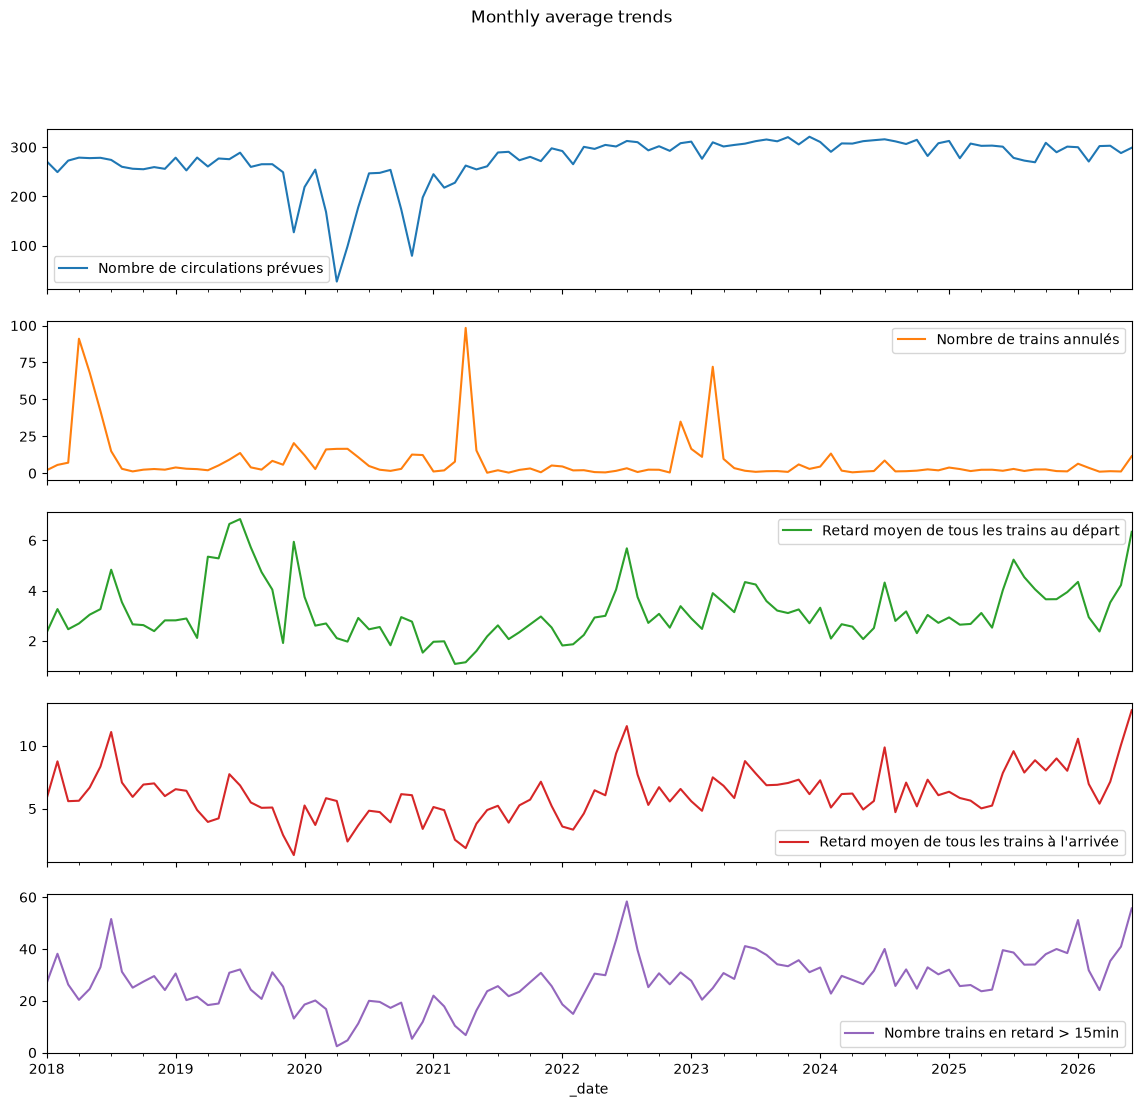

In [7]:
# Convert dates and create monthly summaries
dates = pd.to_datetime(df["Date"], format="%Y-%m", errors="coerce")

metrics = [
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Retard moyen de tous les trains au départ",
    "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min",
]

monthly = (
    df.assign(_date=dates)
      .groupby("_date")[metrics]
      .mean()
)

# Monthly trends
monthly.plot(
    subplots=True,
    figsize=(14, 12),
    sharex=True,
    title="Monthly average trends"
)

